In [1]:
import os

# Subir un nivel respecto a la carpeta actual
os.chdir("..")

import numpy as np
from globals import SAMPLE_RATE
import librosa
import matplotlib.pyplot as plt
from IPython.display import Audio, display

from Utils import from_matrix_to_preset, denormalize_preset, pretty_print, get_audio, split_audio
import numpy as np
import matplotlib.pyplot as plt
from Optimizers import search_with_DE, search_with_CMA, evaluate_target, render_presets

c:\Users\bryan\Documents\GitHub\Synth\Utils.py:505: UserWarning: PySoundFile failed. Trying audioread instead.
  y, _sr = librosa.load(audio_path, sr=SAMPLE_RATE)
c:\Users\bryan\Documents\GitHub\Synth\venv\Lib\site-packages\librosa\core\audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


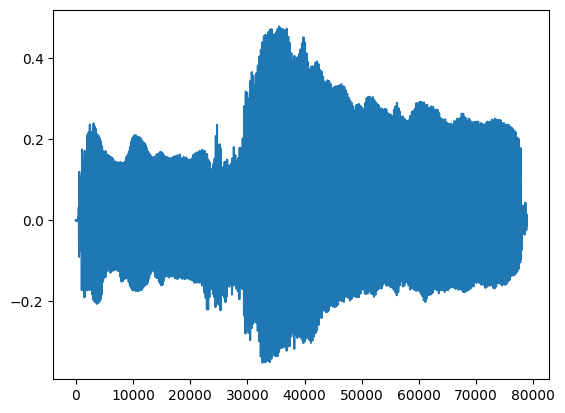

In [2]:
audio_path = 'C:/Users/bryan/Documents/GitHub/Synth/presets/Voz.m4a'
audio = get_audio(audio_path)

plt.plot(audio)
plt.show()
Audio(audio, rate=SAMPLE_RATE)

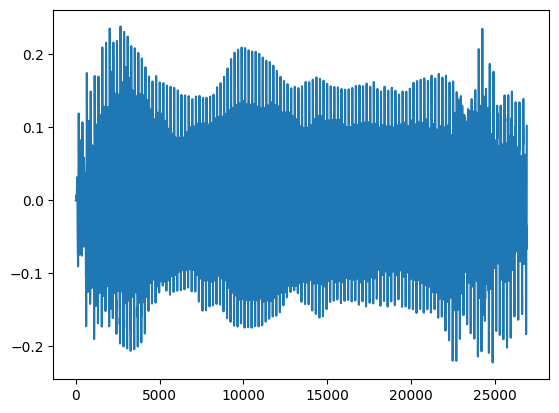

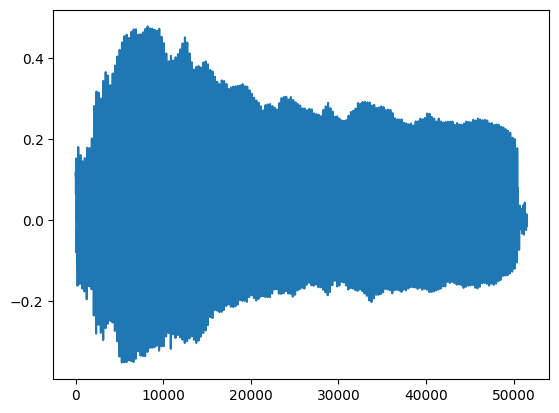

Pieces 2


In [3]:
audio_segments = split_audio(audio, prominence=0.04)

for audio_segment in audio_segments:
    plt.plot(audio_segment)
    plt.show()
    display(Audio(audio_segment, rate=SAMPLE_RATE))

print('Pieces', len(audio_segments))

In [4]:
estimated_presets = []
i = 1
last_best = None

if __name__ == '__main__':
    for audio_segment in audio_segments:
        print('Piece', i)
        target_C = evaluate_target(np.expand_dims(audio_segment, axis=0))
        duration = len(audio_segment) / SAMPLE_RATE
        if last_best is None:
            best = search_with_DE(target_C, duration, disp=False, maxiter=200)
            best = search_with_CMA(target_C, duration, best)
        else:
            best = search_with_CMA(target_C, duration, last_best)

        last_best = best
        estimated_presets.append((best, duration))
        i+=1

Piece 1


c:\Users\bryan\Documents\GitHub\Synth\venv\Lib\site-packages\scipy\optimize\_differentialevolution.py:487: UserWarning: differential_evolution: the 'vectorized' keyword has overridden updating='immediate' to updating='deferred'
  with DifferentialEvolutionSolver(func, bounds, args=args,


(15_w,30)-aCMA-ES (mu_w=8.6,w_1=20%) in dimension 29 (seed=942484, Wed Feb 11 18:54:09 2026)
(15_w,30)-aCMA-ES (mu_w=8.6,w_1=20%) in dimension 29 (seed=911152, Wed Feb 11 18:55:26 2026)
(15_w,30)-aCMA-ES (mu_w=8.6,w_1=20%) in dimension 29 (seed=982003, Wed Feb 11 18:58:11 2026)
Piece 2
(15_w,30)-aCMA-ES (mu_w=8.6,w_1=20%) in dimension 29 (seed=1033020, Wed Feb 11 18:59:25 2026)
(15_w,30)-aCMA-ES (mu_w=8.6,w_1=20%) in dimension 29 (seed=1006567, Wed Feb 11 19:00:09 2026)
(15_w,30)-aCMA-ES (mu_w=8.6,w_1=20%) in dimension 29 (seed=962168, Wed Feb 11 19:01:00 2026)


In [5]:
predicted_joined_audio = []

for preset, duration in estimated_presets:
    preset = np.expand_dims(preset, axis=0)
    # error = evaluate_presets((denormalize_preset(from_matrix_to_preset(preset)), target_C, duration))
    # print('Error', error)
    # target_audio = np.expand_dims(audio_segments[0], axis=0)
    predicted_audio = render_presets(denormalize_preset(from_matrix_to_preset(preset)), duration)
    predicted_joined_audio.append(predicted_audio[0])

    denormalized_predicted_preset = denormalize_preset(from_matrix_to_preset(preset))
    pretty_print(denormalized_predicted_preset)

predicted_joined_audio = np.concatenate(predicted_joined_audio, axis=0)

{
  osc1_shape:   [
    3.1099538453389726
  ]
  osc1_phase:   [
    0.5279989993636104
  ]
  osc1_volume:   [
    0.02989986134643921
  ]
  osc1_freq:   [
    480.86613866822984
  ]
  osc2_shape:   [
    0.08679256212289349
  ]
  osc2_phase:   [
    0.46033275959734854
  ]
  osc2_volume:   [
    0.33208726493470014
  ]
  osc2_freq:   [
    3340.3974234599946
  ]
  osc3_shape:   [
    1.827300667579791
  ]
  osc3_phase:   [
    0.9692646539630668
  ]
  osc3_volume:   [
    0.9719874475081052
  ]
  osc3_freq:   [
    205.84685276229214
  ]
  osc4_shape:   [
    0.1645092656035298
  ]
  osc4_phase:   [
    0.04104946214948704
  ]
  osc4_volume:   [
    0.4628256276523294
  ]
  osc4_freq:   [
    22049.47465064576
  ]
  oscnoise_volume:   [
    0.30139152236690275
  ]
  filter_envelope_attack:   [
    0.499999599270001
  ]
  filter_envelope_decay:   [
    0.18543103613656403
  ]
  filter_envelope_sustain:   [
    0.622728853234868
  ]
  filter_envelope_release:   [
    0.06449802317892236

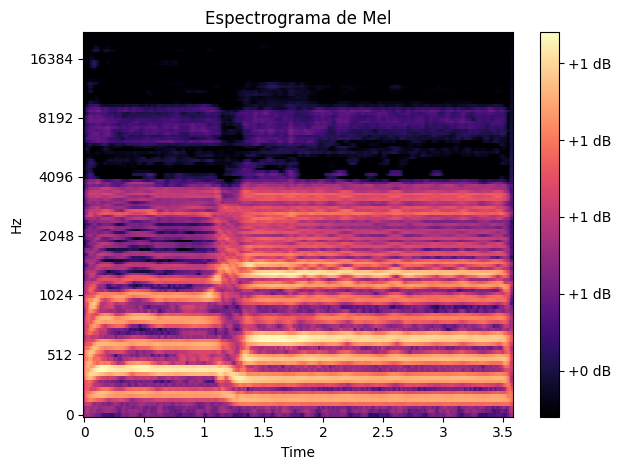

In [6]:
spect = evaluate_target(np.array([audio]))[0]
librosa.display.specshow(spect, sr=SAMPLE_RATE, x_axis='time', y_axis='mel')
plt.colorbar(format='%+2.0f dB')
plt.title('Espectrograma de Mel')
plt.tight_layout()
plt.show()

display(Audio(audio, rate=SAMPLE_RATE))

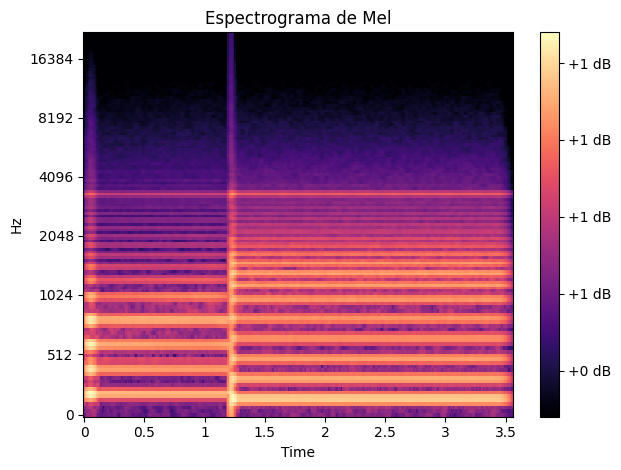

In [7]:
spect = evaluate_target(np.array([predicted_joined_audio]))[0]
librosa.display.specshow(spect, sr=SAMPLE_RATE, x_axis='time', y_axis='mel')
plt.colorbar(format='%+2.0f dB')
plt.title('Espectrograma de Mel')
plt.tight_layout()
plt.show()

display(Audio(predicted_joined_audio, rate=SAMPLE_RATE))